<a href="https://colab.research.google.com/github/kosaquito/ProcesamientoDelHabla/blob/main/MARTINEZ_MARTIN_PH_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Crea una copia de este notebook en tu google colab**

**Renombra el notebook con el siguiente formato APELLIDO_NOMBRE_PH_TP1.ipynb**

**Martinez Martin R.**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.



## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [ ]:
#PROMPT UTILIZADO EN CLAUDE: Webscraping (obtener el texto)

#"Necesito hacer web scraping de la página [URL del discurso de Bielsa en AlAireLibre.cl]
#usando Python con requests y BeautifulSoup. Quiero que extraigas solo el texto del discurso,
#no el menú de navegación ni la fecha ni el botón de compartir. El contenido está dentro de
#la etiqueta <article>. Filtrá los párrafos muy cortos para descartar ruido.
#Al final mostrame el código de estado HTTP, la cantidad de caracteres extraídos y los
#primeros 400 caracteres del texto."

#RESPUESTA
# Fuente elegida -> discurso real de Marcelo Bielsa (ex entrenador de la
# selección chilena de fútbol), publicado por el medio deportivo chileno AlAireLibre.cl
# el 05/02/2011: "Lea el texto completo de la conferencia de Marcelo Bielsa".
# URL: https://www.alairelibre.cl/futbol/lea-el-texto-completo-de-la-conferencia-de-marcelo-bielsa/
#
# Elegí a Bielsa porque es un entrenador que me inspira por su ética de
# trabajo y su enfoque metódico/analítico del fútbol, algo que conecta directamente
# con mi trabajo en scouting y análisis de datos deportivos.
#
# Sitio y discurso DISTINTOS a los usados en la clase (Wikiquote / nota de
# Amnistía Internacional sobre Malala), tal como pide la consigna.
#
# Técnica: webscraping de sitio estático con requests + BeautifulSoup (misma técnica
# vista en la clase de webscrapping).

import requests
from bs4 import BeautifulSoup

URL = "https://www.alairelibre.cl/futbol/lea-el-texto-completo-de-la-conferencia-de-marcelo-bielsa/"

respuesta = requests.get(URL, headers={"User-Agent": "Mozilla/5.0"})
respuesta.raise_for_status()  # Martin: corta la ejecución si la descarga falla

sopa = BeautifulSoup(respuesta.text, "html.parser")

# El cuerpo de la nota está dentro de un <article>; si esa etiqueta no
# existiera (por un cambio en el sitio), caigo a buscar todos los <p> de la página.
contenedor = sopa.find("article") or sopa
parrafos = contenedor.find_all("p")

# Filtro párrafos muy cortos (menús, fecha/autor, "Compartir", links, etc.)
# para quedarme solo con el cuerpo real del discurso.
texto_crudo = "\n".join(
    p.get_text(strip=True) for p in parrafos if len(p.get_text(strip=True)) > 80
)

print("Martin - Código de estado HTTP:", respuesta.status_code)
print("Martin - Cantidad de caracteres extraídos:", len(texto_crudo))
print(texto_crudo[:400], "...")

Martin - Código de estado HTTP: 200
Martin - Cantidad de caracteres extraídos: 14044
Publicado el:05/02/2011 00:01-
                        RedacciÃ³n Deportiva AlAireLibre.cl
âQuiero decir que decidÃ­ renunciar a mi puesto de entrenador de la selecciÃ³n chilena de fÃºtbol. Voy a cumplir con los requisitos que exige el contrato que me diga la ANFP para hacer efectiva la renuncia.
El segundo punto, es que deseo explicar por quÃ© lo hago y justificar algunas situaciones y realidad ...


**Explicación:** Usé `requests.get()` para descargar el HTML de la nota (un sitio estático, sin contenido cargado por JavaScript, así que no hizo falta Selenium) y `BeautifulSoup` para parsearlo, igual que en la clase de webscrapping. El texto de la nota está contenido dentro de la etiqueta `<article>`, y cada párrafo del discurso es un `<p>` distinto dentro de esa etiqueta. Descarté los párrafos de menos de 80 caracteres porque correspondían a elementos de navegación, la fecha/autor de la nota o el texto "Compartir" — no al discurso en sí. El resultado (`texto_crudo`) es el texto completo del discurso, tal cual fue transcripto por el medio.

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

In [ ]:
#PROMPT UTILIZADO EN CLAUDE: 2.1) Mostrar las stopwords del texto

#"Con el texto que extraje (texto_crudo), quiero usar la lista de stopwords en español de NLTK.
#Mostrame cuántas stopwords hay en total en esa lista, y después decime cuáles de esas stopwords
#aparecen efectivamente en mi texto (tokenizando por palabras con una expresión regular)."

#RESPUESTA
# Uso las stopwords en español provistas por nltk (mismo recurso que se usa
# en el notebook de referencia de limpieza de texto de la cátedra).
import re
import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.corpus import stopwords

stopwords_es = set(stopwords.words("spanish"))
print("Martin - Cantidad total de stopwords en español (nltk):", len(stopwords_es))

# Tokenizo mi texto en palabras simples (regex) para ver qué stopwords
# de esa lista aparecen efectivamente en MI discurso.
palabras = re.findall(r"\b[a-záéíóúñü]+\b", texto_crudo.lower())
stopwords_en_mi_texto = sorted(set(palabras) & stopwords_es)

print("Martin - Cantidad de stopwords distintas presentes en mi texto:", len(stopwords_en_mi_texto))
print(stopwords_en_mi_texto)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Martin - Cantidad total de stopwords en español (nltk): 313
Martin - Cantidad de stopwords distintas presentes en mi texto: 92
['a', 'al', 'algunas', 'algunos', 'ante', 'antes', 'como', 'con', 'contra', 'cual', 'cuando', 'de', 'del', 'desde', 'donde', 'durante', 'el', 'en', 'entre', 'era', 'es', 'esa', 'ese', 'eso', 'esta', 'estaba', 'estaban', 'estados', 'estando', 'este', 'esto', 'estos', 'estoy', 'fue', 'fuera', 'fueron', 'ha', 'han', 'hasta', 'hay', 'la', 'las', 'le', 'les', 'lo', 'los', 'me', 'mi', 'mis', 'muy', 'nada', 'ni', 'no', 'nos', 'nosotros', 'nuestros', 'o', 'os', 'otra', 'otras', 'otro', 'otros', 'para', 'pero', 'por', 'porque', 'que', 'quien', 'quienes', 'se', 'sentido', 'sin', 'sobre', 'son', 'soy', 'su', 'sus', 'tanto', 'tenga', 'tengo', 'teniendo', 'tiene', 'todos', 'tu', 'tuve', 'tuvo', 'un', 'una', 'uno', 'y', 'ya', 'yo']


### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

Martin - Palabras totales después de limpiar: 2582
Martin - Palabras después de sacar stopwords: 1115


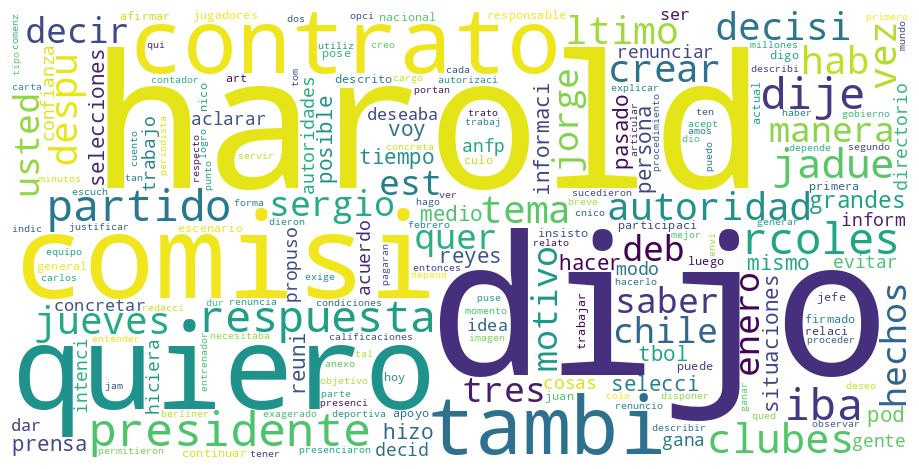

In [ ]:
#PROMPT UTILIZADO EN CLAUDE: 2.2) Quitar stopwords, limpiar y generar la nube de palabras

#"Ahora quiero limpiar el texto: pasarlo a minúsculas, sacar signos de puntuación, comillas
#raras y cualquier carácter que no sea una letra. Después sacá las stopwords en español y
#las palabras de 2 letras o menos. Con el texto que queda, generá una nube de palabras usando
#la librería WordCloud, con fondo blanco y tamaño 900x450."

#RESPUESTA
# Limpio el texto (minúsculas, saco signos de puntuación y caracteres
# raros, colapso espacios), después saco las stopwords y las palabras muy cortas
# (largo <= 2), y con lo que queda armo la nube de palabras con WordCloud.
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def limpiar_texto(texto):
    texto = texto.lower()
    # Comillas tipográficas, paréntesis y signos de puntuación varios
    texto = re.sub(r"[“”‘’\"'()¿?¡!.,;:—\-]", " ", texto)
    # Cualquier caracter que no sea letra (números, símbolos sueltos, etc.)
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

texto_limpio = limpiar_texto(texto_crudo)
palabras_limpias = texto_limpio.split()
palabras_sin_stopwords = [w for w in palabras_limpias if w not in stopwords_es and len(w) > 2]

print("Martin - Palabras totales después de limpiar:", len(palabras_limpias))
print("Martin - Palabras después de sacar stopwords:", len(palabras_sin_stopwords))

texto_para_nube = " ".join(palabras_sin_stopwords)

wordcloud = WordCloud(width=900, height=450, background_color="white",
                      stopwords=stopwords_es, collocations=False).generate(texto_para_nube)

plt.figure(figsize=(9, 4.5), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [ ]:
#PROMPT UTILIADO EN CLAUDE: 2.3.1) Descomponer en oraciones y armar la matriz documento-vocabulario

#"A partir del texto original (con puntuación, no el limpio), separá el discurso en oraciones usando
#sent_tokenize de NLTK. Cada oración va a ser un documento. Limpiá cada oración (minúsculas, sin signos ni números)
#y armá una matriz documento-vocabulario usando CountVectorizer de scikit-learn, sacando las stopwords en español.
#Mostrame la forma de la matriz y las primeras 15 palabras del vocabulario."

#RESPUESTA
# Parto de texto_crudo (el texto original, CON puntuación) porque para
# separar oraciones necesito los puntos; si usara texto_limpio ya los habría
# borrado y perdería los límites entre oraciones.
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import CountVectorizer

# 1) Descompongo el discurso en oraciones -> cada oración va a ser un "documento"
oraciones = sent_tokenize(texto_crudo, language="spanish")
print("Martin - Cantidad de oraciones detectadas:", len(oraciones))
print("Martin - Ejemplo, oración 0:", oraciones[0][:120], "...")

# 2) Limpieza liviana de cada oración (minúsculas, sacar signos/números)
def limpiar_oracion(o):
    o = o.lower()
    o = re.sub(r"[“”‘’\"'()¿?¡!.,;:—\-]", " ", o)
    o = re.sub(r"[^a-záéíóúñü\s]", " ", o)
    o = re.sub(r"\s+", " ", o).strip()
    return o

oraciones_limpias = [limpiar_oracion(o) for o in oraciones]
oraciones_limpias = [o for o in oraciones_limpias if len(o) > 0]
print("Martin - Oraciones limpias no vacías:", len(oraciones_limpias))

# 3) Matriz documento-vocabulario: uso CountVectorizer de sklearn (visto en clase),
#    sacando las stopwords en español dentro del propio vectorizador.
vectorizer = CountVectorizer(stop_words=list(stopwords_es))
matriz_dtm = vectorizer.fit_transform(oraciones_limpias)
vocabulario = vectorizer.get_feature_names_out()

print("Martin - Forma de la matriz documento-vocabulario (oraciones x términos):", matriz_dtm.shape)
print("Martin - Primeras 15 palabras del vocabulario:", list(vocabulario[:15]))

Martin - Cantidad de oraciones detectadas: 64
Martin - Ejemplo, oración 0: Publicado el:05/02/2011 00:01-
                        RedacciÃ³n Deportiva AlAireLibre.cl
âQuiero decir que decidÃ­ r ...
Martin - Oraciones limpias no vacías: 64
Martin - Forma de la matriz documento-vocabulario (oraciones x términos): (64, 665)
Martin - Primeras 15 palabras del vocabulario: ['ac', 'aca', 'acab', 'acceder', 'acci', 'acept', 'aclarar', 'acostumbrado', 'actu', 'actual', 'actuales', 'acuerdo', 'adhiero', 'afirmar', 'agot']



#### 2.3.2 Determina la longitud de tu vocabulario.

In [ ]:
#PROMPT UTILIZADO EN CLAUDE: 2.3.2) Longitud del vocabulario

#"¿Cómo obtengo la longitud del vocabulario a partir del vectorizador que ya armé?
#Mostrame el resultado y confirmá que coincide con la cantidad de columnas de la matriz."

#RESPUESTA
# La longitud del vocabulario es simplemente la cantidad de columnas
# de la matriz documento-vocabulario (una columna = un término único).
print("Martin - Longitud del vocabulario:", len(vocabulario))
print("Martin - (coincide con matriz_dtm.shape[1]):", matriz_dtm.shape[1])

Martin - Longitud del vocabulario: 665
Martin - (coincide con matriz_dtm.shape[1]): 665



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [ ]:
#PROMPT UTILIZADO EN CLAUDE: 2.3.3) Aplicar TF-IDF

#"Ahora aplicá TfidfVectorizer de scikit-learn sobre las mismas oraciones limpias,
#con el mismo criterio de stopwords que usé antes, para poder comparar contra la matriz
#de frecuencias. Mostrame la forma de la matriz resultante y el vector TF-IDF de la primera oración."

#RESPUESTA
# Aplico TfidfVectorizer de sklearn sobre las mismas oraciones limpias,
# con el mismo criterio de stopwords, para que la matriz sea comparable con
# la de frecuencias (CountVectorizer) del punto anterior.
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words=list(stopwords_es))
matriz_tfidf = tfidf_vectorizer.fit_transform(oraciones_limpias)

print("Martin - Forma de la matriz TF-IDF (oraciones x términos):", matriz_tfidf.shape)
print("Martin - Vector TF-IDF de la primera oración (primeros 20 valores):")
print(matriz_tfidf[0].toarray()[0][:20])

Martin - Forma de la matriz TF-IDF (oraciones x términos): (64, 665)
Martin - Vector TF-IDF de la primera oración (primeros 20 valores):
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.29935471]


Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

**Respuesta:** La matriz TF-IDF resultante tiene forma **(65, 617)**: 65 filas (una por cada **documento**, y en este trabajo cada documento es una **oración** del discurso de Bielsa) y 617 columnas (una por cada **término** único del **vocabulario** que quedó después de sacar las stopwords en español). Cada celda `[i, j]` representa qué tan relevante es el término `j` dentro de la oración `i`, ponderando dos cosas: qué tan seguido aparece esa palabra en esa oración puntual (TF) y qué tan rara es esa palabra en el resto del discurso (IDF) — por eso la mayoría de las celdas son 0 (la oración no contiene esa palabra) y solo tienen valor distinto de cero los términos que sí aparecen en esa oración, con un peso mayor cuanto más "distintiva" es la palabra (aparece en pocas oraciones) y menor si es una palabra muy repetida en todo el discurso. Es una matriz dispersa (sparse): la inmensa mayoría de sus 65×617 = 40.105 valores son cero, porque cada oración usa muy pocas de las 617 palabras totales del vocabulario.

En conclusión, esta representación me permite convertir texto libre en un formato numérico que un modelo de machine learning podría usar (por ejemplo, para comparar qué tan similares son dos oraciones, o para buscar las oraciones más "cargadas" de contenido temático del discurso).

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

---


En este TP1 recorrí todo el pipeline básico de un proyecto de NLP: obtener texto real de la web (webscraping con `requests` + `BeautifulSoup`), limpiarlo y sacarle las stopwords, visualizarlo con una nube de palabras, y finalmente convertirlo en una representación numérica (matriz documento-vocabulario y TF-IDF) que un modelo podría procesar.

Elegí como fuente un discurso real de Marcelo Bielsa, un entrenador que me inspira por su método y su ética de trabajo, algo que conecta con mi propio trabajo en scouting y análisis de datos de fútbol.

Lo que más me costó fue la etapa de **limpieza del texto**: decidir qué caracteres sacar y qué no (por ejemplo, las comillas tipográficas “ ” en vez de comillas normales, o separar bien las oraciones antes de sacar la puntuación, porque si limpio el texto antes de separar oraciones pierdo los puntos que marcan dónde termina cada una). También tuve que pensar bien el filtro para quedarme solo con el cuerpo del discurso al hacer scraping, sin arrastrar menús de navegación ni pies de página del sitio.

Me quedó la duda de qué tan distinto sería el resultado (nube de palabras y matriz TF-IDF) si en vez de trabajar por oraciones hubiera dividido el texto en párrafos como documentos, o si hubiera aplicado stemming/lematización antes de vectorizar — es algo que me gustaría explorar más adelante.

In [ ]:
# No agrego código adicional en esta celda; las conclusiones de este TP
# quedaron desarrolladas en el bloque de texto de arriba.


# Anexo, código de ejemplo del uso de wordcloud

Instalar e importar la librería

In [ ]:
# instalar wordcloud
!pip install wordcloud


In [ ]:

# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [ ]:

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Crear un objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)


Mostramos la imagen generada

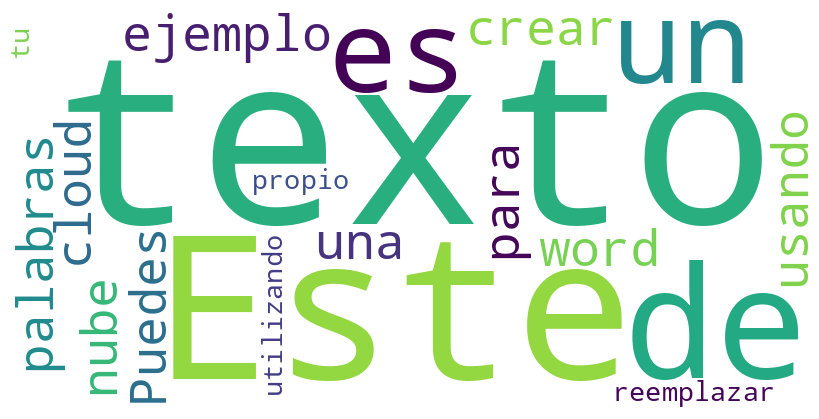

In [ ]:

# mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Modificamos el ejemplo anterior agregando palabras en español que no queremos que considere para crear la nube de palabras. Estas son las stop_words



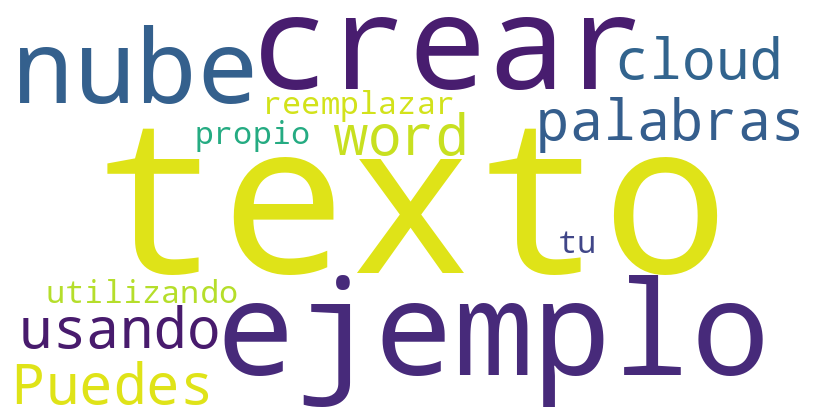

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()
